<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_lab5_CNN_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# No extra install needed -- this notebook downloads the dataset directly from
# Oxford's own server using core TensorFlow only, avoiding the tensorflow_datasets /
# tensorflow_metadata / protobuf dependency chain entirely (which is fragile on some
# Colab images). Nothing to run in this cell; kept as a placeholder for clarity.
print("No additional packages required -- using tf.keras.utils.get_file only.")

No additional packages required -- using tf.keras.utils.get_file only.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

from sklearn.model_selection import KFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 224

In [7]:
import os
import tarfile

DATA_DIR = "/content/oxford_pets" if os.path.isdir("/content") else "./oxford_pets"
os.makedirs(DATA_DIR, exist_ok=True)


def download_and_extract(filename, url, extract_to):
    """Downloads (if not already present) and extracts a .tar.gz explicitly via `tarfile`,
    with verification prints at each step so any structural surprise is immediately visible
    here rather than causing a confusing FileNotFoundError several cells later."""
    archive_path = tf.keras.utils.get_file(filename, url, extract=False, cache_dir=DATA_DIR, cache_subdir="")
    size_mb = os.path.getsize(archive_path) / (1024 * 1024)
    print(f"  Downloaded {filename}: {size_mb:.1f} MB at {archive_path}")
    if size_mb < 1:
        raise RuntimeError(
            f"{filename} is suspiciously small ({size_mb:.2f} MB) -- the download likely failed "
            f"(e.g. the server returned an error page instead of the real archive). "
            f"Check that {url} is reachable from this Colab session."
        )

    with tarfile.open(archive_path) as tar:
        top_level_names = sorted(set(n.split("/")[0] for n in tar.getnames()))
        print(f"  Archive top-level contents: {top_level_names}")
        tar.extractall(extract_to)
    print(f"  Extracted into {extract_to}")


print("Downloading and extracting images.tar.gz (this can take a few minutes the first time)...")
download_and_extract(
    "images.tar.gz",
    "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
    DATA_DIR
)

print("\nDownloading and extracting annotations.tar.gz...")
download_and_extract(
    "annotations.tar.gz",
    "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz",
    DATA_DIR
)

IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATA_DIR, "annotations")

# Defensive fallback: if the expected folders aren't where assumed, search for them
# instead of failing with an opaque FileNotFoundError.
def locate_dir_containing(root, target_filename):
    for dirpath, _, filenames in os.walk(root):
        if target_filename in filenames:
            return dirpath
    return None

if not os.path.isfile(os.path.join(ANNOTATIONS_DIR, "trainval.txt")):
    print(f"\nWARNING: trainval.txt not found at the expected path {ANNOTATIONS_DIR}. Searching {DATA_DIR}...")
    found_dir = locate_dir_containing(DATA_DIR, "trainval.txt")
    if found_dir is None:
        raise FileNotFoundError(
            f"Could not find trainval.txt anywhere under {DATA_DIR}. "
            f"Contents of {DATA_DIR}: {os.listdir(DATA_DIR)}. "
            f"The download may have failed or the archive structure has changed -- "
            f"inspect the printed archive contents above for clues."
        )
    print(f"Found it at: {found_dir} -- using this as ANNOTATIONS_DIR instead.")
    ANNOTATIONS_DIR = found_dir

if not os.path.isdir(IMAGES_DIR) or len(os.listdir(IMAGES_DIR)) == 0:
    print(f"\nWARNING: no images found at the expected path {IMAGES_DIR}. Searching {DATA_DIR}...")
    for dirpath, dirnames, filenames in os.walk(DATA_DIR):
        jpgs = [f for f in filenames if f.lower().endswith(".jpg")]
        if len(jpgs) > 100:  # the real images folder has ~7,000 images; any correct match will be large
            print(f"Found a large folder of .jpg files at: {dirpath} -- using this as IMAGES_DIR instead.")
            IMAGES_DIR = dirpath
            break

print(f"\nFinal IMAGES_DIR:      {IMAGES_DIR}")
print(f"Final ANNOTATIONS_DIR: {ANNOTATIONS_DIR}")


def parse_split_file(filepath):
    """Parses trainval.txt / test.txt: each line is 'filename class_id species breed_id'."""
    filenames, labels = [], []
    with open(filepath) as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split()
            fname, class_id = parts[0], int(parts[1])
            filenames.append(fname + ".jpg")
            labels.append(class_id - 1)  # convert the dataset's 1-indexed classes to 0-indexed
    return filenames, labels


train_files, train_labels_raw = parse_split_file(os.path.join(ANNOTATIONS_DIR, "trainval.txt"))
test_files, test_labels_raw = parse_split_file(os.path.join(ANNOTATIONS_DIR, "test.txt"))


def breed_name_from_filename(fname):
    # Breed name is everything before the final "_<number>" in the filename,
    # e.g. "Abyssinian_100.jpg" -> "Abyssinian"
    stem = fname.rsplit(".", 1)[0]
    return stem.rsplit("_", 1)[0]


label_to_name = {}
for fname, lbl in zip(train_files, train_labels_raw):
    label_to_name.setdefault(lbl, breed_name_from_filename(fname))
CLASS_NAMES = [label_to_name[i] for i in range(len(label_to_name))]
NUM_CLASSES = len(CLASS_NAMES)


def load_image(fname):
    path = tf.strings.join([IMAGES_DIR, "/", fname])
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img


def make_dataset(files, labels):
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    ds = ds.map(lambda f, l: (load_image(f), l), num_parallel_calls=tf.data.AUTOTUNE)
    return ds


train_full = make_dataset(train_files, train_labels_raw)
test_raw = make_dataset(test_files, test_labels_raw)

print("\nNumber of classes:", NUM_CLASSES)
print("Training+validation pool size:", len(train_files))
print("Official test set size       :", len(test_files))

  Downloaded images.tar.gz: 755.2 MB at /content/oxford_pets/images.tar.gz
  Archive top-level contents: ['images']


/tmp/ipykernel_94912/3577513242.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_to)


  Extracted into /content/oxford_pets

  Downloaded annotations.tar.gz: 18.3 MB at /content/oxford_pets/annotations.tar.gz
  Archive top-level contents: ['annotations']
  Extracted into /content/oxford_pets

Final IMAGES_DIR:      /content/oxford_pets/images
Final ANNOTATIONS_DIR: /content/oxford_pets/annotations

Number of classes: 37
Training+validation pool size: 3680
Official test set size       : 3669


In [8]:
# Carve a validation set out of the training pool (85/15), keep the official test set untouched
train_full_size = len(train_files)
val_size = int(0.15 * train_full_size)

train_full_shuffled = train_full.shuffle(train_full_size, seed=42, reshuffle_each_iteration=False)
val_raw = train_full_shuffled.take(val_size)
train_raw = train_full_shuffled.skip(val_size)

print(f"Training set  : {train_full_size - val_size} images")
print(f"Validation set: {val_size} images")
print(f"Test set      : {len(test_files)} images (untouched until Section 12)")

Training set  : 3128 images
Validation set: 552 images
Test set      : 3669 images (untouched until Section 12)


In [9]:
def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(image)  # normalizes per MobileNetV2's expected input range
    return image, label

def make_pipeline(ds, batch_size=32, shuffle=False, cache_name=None):
    ds = ds.map(lambda x, y: preprocess(x, y), num_parallel_calls=tf.data.AUTOTUNE)
    if cache_name:
        ds = ds.cache()
    if shuffle:M
        ds = ds.shuffle(1000, seed=42)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_pipeline(train_raw, batch_size=32, shuffle=True)
val_ds = make_pipeline(val_raw, batch_size=32)
test_ds = make_pipeline(test_raw, batch_size=32)

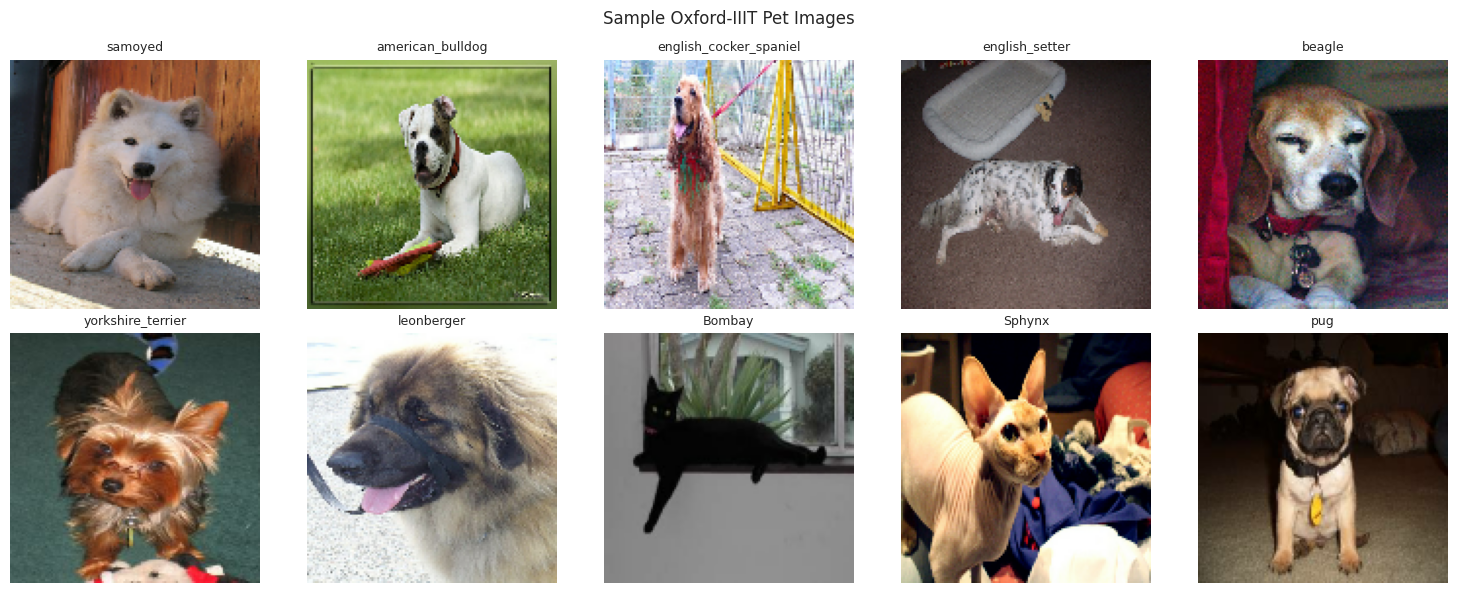

In [10]:
# ---- Sample images ----
# Oxford-IIIT Pet images have different native dimensions, so they can't be batched
# together before resizing -- take them individually and resize each just for display.
sample_pairs = list(train_raw.take(10).as_numpy_iterator())

plt.figure(figsize=(15, 6))
for i, (img, label) in enumerate(sample_pairs):
    img_resized = tf.image.resize(img, (128, 128)).numpy().astype("uint8")
    plt.subplot(2, 5, i + 1)
    plt.imshow(img_resized)
    plt.title(CLASS_NAMES[label], fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Oxford-IIIT Pet Images")
plt.tight_layout()
plt.show()

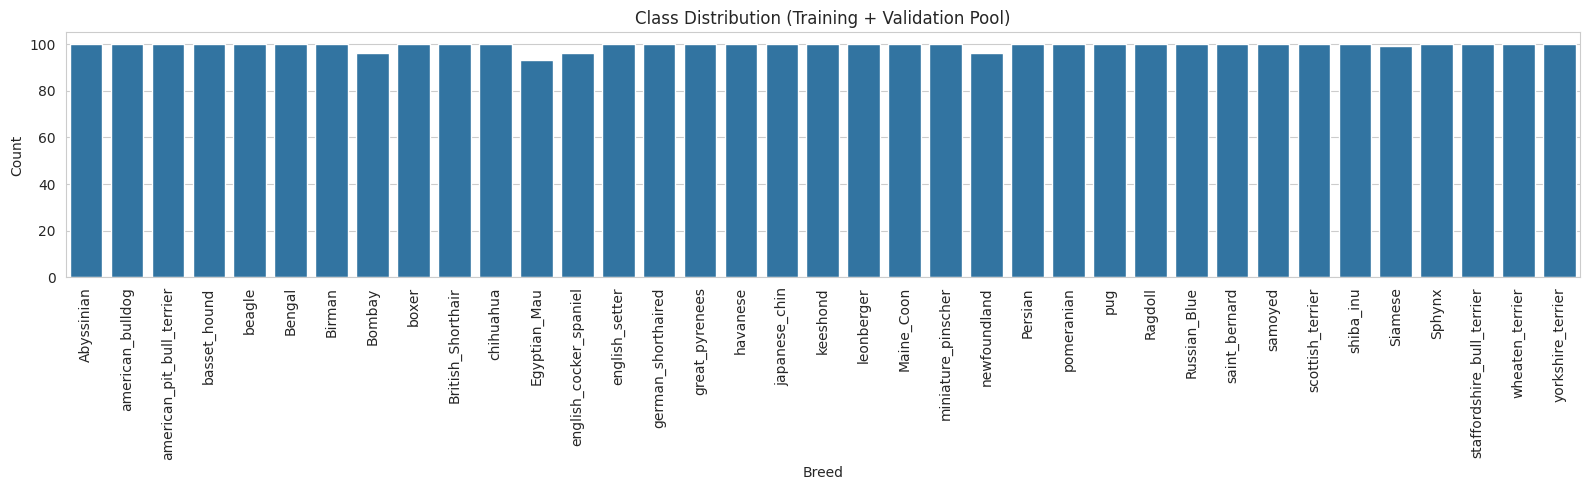

In [11]:
# ---- Class distribution (training pool) ----
all_labels = np.array([label.numpy() for _, label in train_full])

plt.figure(figsize=(16, 5))
sns.countplot(x=all_labels)
plt.xticks(ticks=range(NUM_CLASSES), labels=CLASS_NAMES, rotation=90)
plt.xlabel("Breed")
plt.ylabel("Count")
plt.title("Class Distribution (Training + Validation Pool)")
plt.tight_layout()
plt.show()

In [9]:
INIT_EPOCHS = 5  # kept small: this section alone trains 4 full models

def build_toy_cnn(initializer, num_classes=NUM_CLASSES):
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(16, 3, activation="relu", kernel_initializer=initializer, padding="same"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, activation="relu", kernel_initializer=initializer, padding="same"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu", kernel_initializer=initializer),
        layers.Dense(num_classes, activation="softmax", kernel_initializer=initializer)
    ])
    return model

initializers_to_test = {
    "Zero": tf.keras.initializers.Zeros(),
    "Random": tf.keras.initializers.RandomNormal(stddev=0.05, seed=42),
    "Xavier/Glorot": tf.keras.initializers.GlorotUniform(seed=42),
    "He": tf.keras.initializers.HeNormal(seed=42),
}

init_histories = {}
for name, init in initializers_to_test.items():
    print(f"\nTraining with {name} initialization...")
    m = build_toy_cnn(init)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(train_ds, validation_data=val_ds, epochs=INIT_EPOCHS, verbose=0)
    init_histories[name] = hist.history
    print(f"  Final training loss: {hist.history['loss'][-1]:.4f} | "
          f"Best val accuracy: {max(hist.history['val_accuracy']):.4f}")


Training with Zero initialization...
  Final training loss: 3.6106 | Best val accuracy: 0.0199

Training with Random initialization...
  Final training loss: 0.1598 | Best val accuracy: 0.1304

Training with Xavier/Glorot initialization...
  Final training loss: 3.2018 | Best val accuracy: 0.0707

Training with He initialization...
  Final training loss: 3.6107 | Best val accuracy: 0.0145


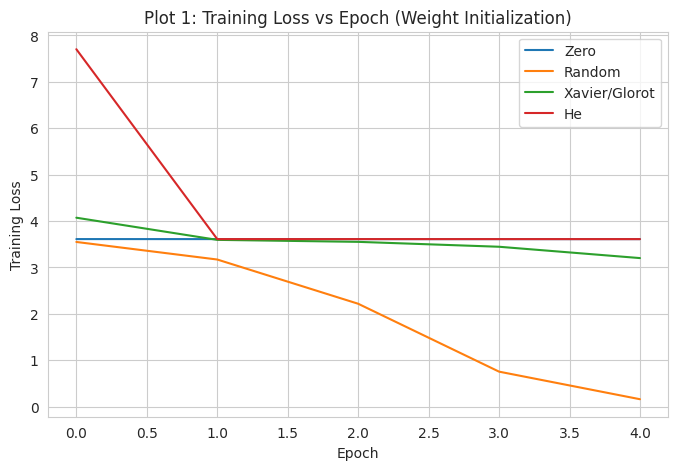

In [10]:
# ---- Plot 1: Training Loss vs Epoch (per initializer) ----
plt.figure(figsize=(8, 5))
for name, hist in init_histories.items():
    plt.plot(hist["loss"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 1: Training Loss vs Epoch (Weight Initialization)")
plt.legend()
plt.show()

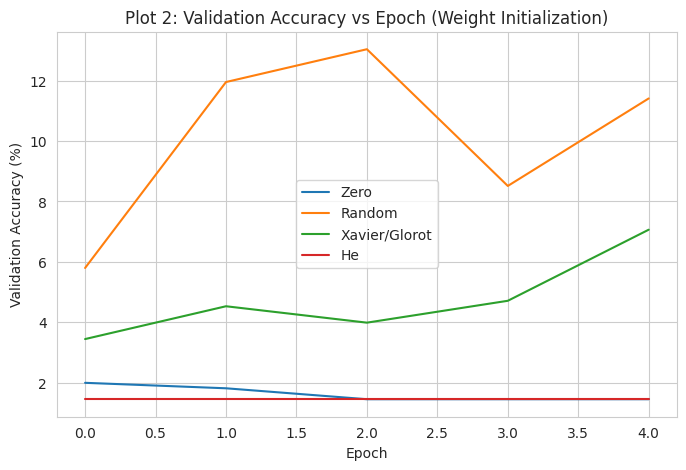

In [11]:
# ---- Plot 2: Validation Accuracy vs Epoch (per initializer) ----
plt.figure(figsize=(8, 5))
for name, hist in init_histories.items():
    plt.plot(np.array(hist["val_accuracy"]) * 100, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 2: Validation Accuracy vs Epoch (Weight Initialization)")
plt.legend()
plt.show()

In [12]:
REG_EPOCHS = 10  # long enough to let overfitting show up in the "none" variant

def build_toy_cnn_reg(reg_type, num_classes=NUM_CLASSES):
    init = tf.keras.initializers.HeNormal(seed=42)
    reg = regularizers.l2(0.001) if reg_type == "l2" else None

    layer_list = [layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))]
    layer_list.append(layers.Conv2D(16, 3, activation="relu", kernel_initializer=init,
                                     kernel_regularizer=reg, padding="same"))
    if reg_type == "batchnorm":
        layer_list.append(layers.BatchNormalization())
    layer_list.append(layers.MaxPooling2D(2))
    layer_list.append(layers.Conv2D(32, 3, activation="relu", kernel_initializer=init,
                                     kernel_regularizer=reg, padding="same"))
    if reg_type == "batchnorm":
        layer_list.append(layers.BatchNormalization())
    layer_list.append(layers.MaxPooling2D(2))
    layer_list.append(layers.Flatten())
    layer_list.append(layers.Dense(64, activation="relu", kernel_initializer=init, kernel_regularizer=reg))
    if reg_type == "dropout":
        layer_list.append(layers.Dropout(0.5))
    layer_list.append(layers.Dense(num_classes, activation="softmax", kernel_initializer=init))

    return models.Sequential(layer_list)

reg_variants = ["none", "l2", "dropout", "batchnorm"]
reg_histories = {}
for reg_type in reg_variants:
    print(f"\nTraining with regularization: {reg_type}")
    m = build_toy_cnn_reg(reg_type)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(train_ds, validation_data=val_ds, epochs=REG_EPOCHS, verbose=0)
    reg_histories[reg_type] = hist.history
    gap = hist.history["accuracy"][-1] - hist.history["val_accuracy"][-1]
    print(f"  Final train acc: {hist.history['accuracy'][-1]:.4f} | "
          f"Final val acc: {hist.history['val_accuracy'][-1]:.4f} | Generalization gap: {gap:.4f}")


Training with regularization: none
  Final train acc: 0.0294 | Final val acc: 0.0145 | Generalization gap: 0.0149

Training with regularization: l2
  Final train acc: 0.0294 | Final val acc: 0.0145 | Generalization gap: 0.0149

Training with regularization: dropout
  Final train acc: 0.0294 | Final val acc: 0.0145 | Generalization gap: 0.0149

Training with regularization: batchnorm
  Final train acc: 0.0278 | Final val acc: 0.0145 | Generalization gap: 0.0133


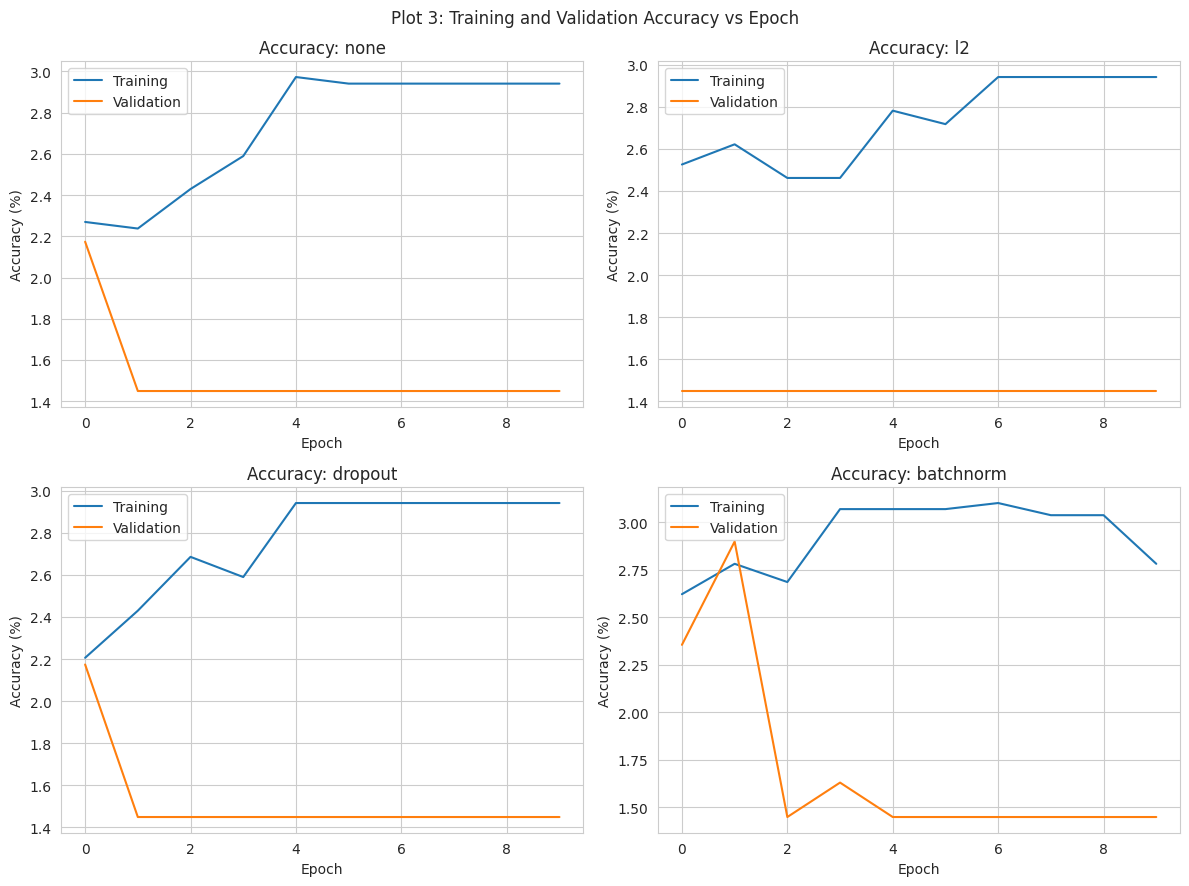

In [13]:
# ---- Plot 3: Training vs Validation Accuracy (one subplot per regularization variant) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, reg_type in zip(axes.flat, reg_variants):
    hist = reg_histories[reg_type]
    ax.plot(np.array(hist["accuracy"]) * 100, label="Training")
    ax.plot(np.array(hist["val_accuracy"]) * 100, label="Validation")
    ax.set_title(f"Accuracy: {reg_type}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend()
plt.suptitle("Plot 3: Training and Validation Accuracy vs Epoch")
plt.tight_layout()
plt.show()

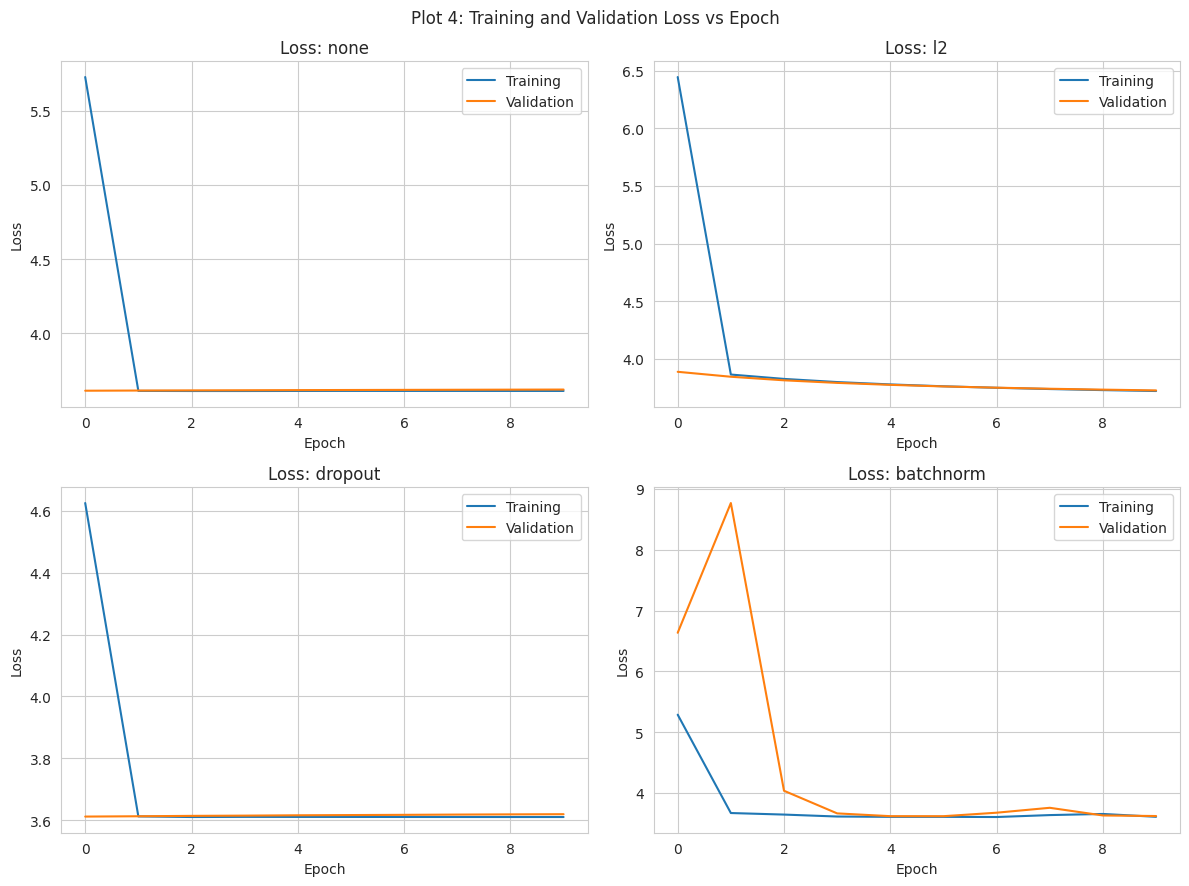

In [14]:
# ---- Plot 4: Training vs Validation Loss (one subplot per regularization variant) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, reg_type in zip(axes.flat, reg_variants):
    hist = reg_histories[reg_type]
    ax.plot(hist["loss"], label="Training")
    ax.plot(hist["val_loss"], label="Validation")
    ax.set_title(f"Loss: {reg_type}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.suptitle("Plot 4: Training and Validation Loss vs Epoch")
plt.tight_layout()
plt.show()

In [12]:
# ---- Numerical example, matching the manual exactly ----
x = np.array([2.0, 4.0, 6.0, 8.0])
mu_B = x.mean()
var_B = ((x - mu_B) ** 2).mean()
std_B = np.sqrt(var_B)
x_hat = (x - mu_B) / std_B

print(f"x = {x.tolist()}")
print(f"Batch mean (mu_B)     = {mu_B}")
print(f"Batch variance (var_B) = {var_B}")
print(f"Std (sqrt(var_B))     = {std_B:.3f}")
print(f"Normalized x_hat      = {np.round(x_hat, 3).tolist()}")

# Verify against Keras's own BatchNormalization layer (gamma=1, beta=0 by default at init)
bn_layer = layers.BatchNormalization(epsilon=1e-10)
x_tf = tf.constant(x.reshape(1, 4, 1), dtype=tf.float32)  # shape (batch=1, features=4, channels=1)
x_hat_tf = bn_layer(x_tf, training=True)
print(f"\nVerified via tf.keras BatchNormalization layer: {np.round(x_hat_tf.numpy().flatten(), 3).tolist()}")

x = [2.0, 4.0, 6.0, 8.0]
Batch mean (mu_B)     = 5.0
Batch variance (var_B) = 5.0
Std (sqrt(var_B))     = 2.236
Normalized x_hat      = [-1.342, -0.447, 0.447, 1.342]

Verified via tf.keras BatchNormalization layer: [-1.3420000076293945, -0.44699999690055847, 0.44699999690055847, 1.3420000076293945]


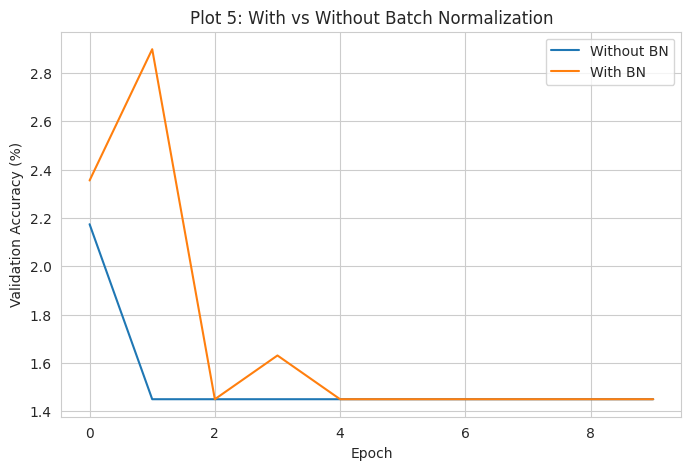

In [16]:
# ---- Plot 5: With vs Without Batch Normalization (reusing Section 6 histories) ----
plt.figure(figsize=(8, 5))
plt.plot(np.array(reg_histories["none"]["val_accuracy"]) * 100, label="Without BN")
plt.plot(np.array(reg_histories["batchnorm"]["val_accuracy"]) * 100, label="With BN")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 5: With vs Without Batch Normalization")
plt.legend()
plt.show()

In [17]:
OPT_EPOCHS = 8  # kept small: this section trains 4 full models

optimizers_to_test = {
    "SGD": SGD(learning_rate=0.01),
    "Momentum": SGD(learning_rate=0.01, momentum=0.9),
    "RMSProp": RMSprop(learning_rate=0.001),
    "Adam": Adam(learning_rate=0.001),
}

opt_histories = {}
opt_results = []
for name, opt in optimizers_to_test.items():
    print(f"\nTraining with optimizer: {name}")
    m = build_toy_cnn_reg("batchnorm")
    m.compile(optimizer=opt, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    start = time.time()
    hist = m.fit(train_ds, validation_data=val_ds, epochs=OPT_EPOCHS, verbose=0)
    elapsed = time.time() - start

    opt_histories[name] = hist.history
    best_val_acc = max(hist.history["val_accuracy"])
    epoch_to_converge = int(np.argmax(hist.history["val_accuracy"])) + 1
    opt_results.append({
        "Optimizer": name, "Final Loss": round(hist.history["loss"][-1], 4),
        "Best Val. Accuracy": round(best_val_acc, 4), "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(elapsed, 2)
    })
    print(f"  Final loss: {hist.history['loss'][-1]:.4f} | Best val acc: {best_val_acc:.4f} | Time: {elapsed:.2f}s")

opt_results_df = pd.DataFrame(opt_results)
display(opt_results_df)


Training with optimizer: SGD
  Final loss: 1.7518 | Best val acc: 0.1069 | Time: 1901.40s

Training with optimizer: Momentum
  Final loss: 3.6108 | Best val acc: 0.0272 | Time: 1876.84s

Training with optimizer: RMSProp
  Final loss: 3.6163 | Best val acc: 0.0236 | Time: 1930.33s

Training with optimizer: Adam
  Final loss: 3.6110 | Best val acc: 0.0362 | Time: 1929.23s


,Optimizer,Final Loss,Best Val. Accuracy,Epoch to Converge,Time (s)
0,SGD,1.7518,0.1069,7,1901.40
1,Momentum,3.6108,0.0272,1,1876.84
2,RMSProp,3.6163,0.0236,2,1930.33
3,Adam,3.6110,0.0362,1,1929.23


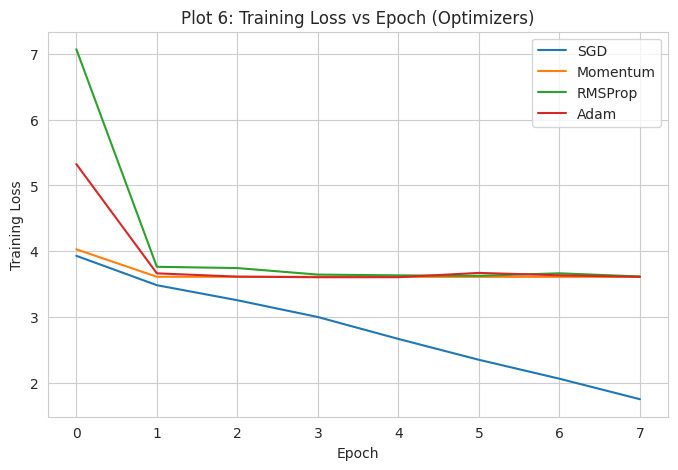

In [18]:
# ---- Plot 6: Training Loss vs Epoch (per optimizer) ----
plt.figure(figsize=(8, 5))
for name, hist in opt_histories.items():
    plt.plot(hist["loss"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Plot 6: Training Loss vs Epoch (Optimizers)")
plt.legend()
plt.show()

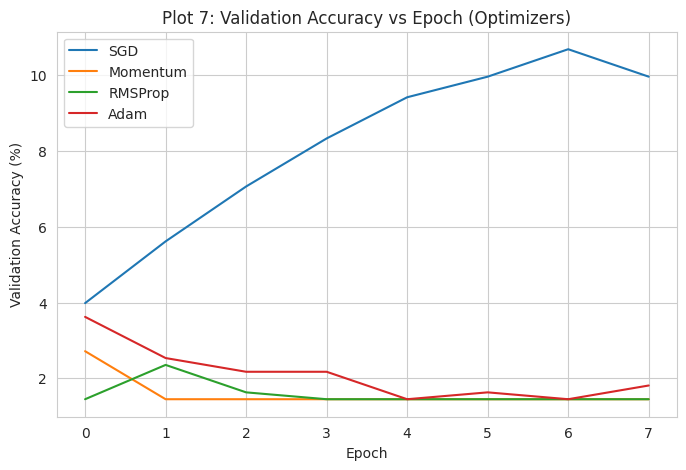

In [19]:
# ---- Plot 7: Validation Accuracy vs Epoch (per optimizer) ----
plt.figure(figsize=(8, 5))
for name, hist in opt_histories.items():
    plt.plot(np.array(hist["val_accuracy"]) * 100, label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 7: Validation Accuracy vs Epoch (Optimizers)")
plt.legend()
plt.show()

In [20]:
# Output-size formula demonstration: O = floor((N + 2P - K) / S) + 1
N_ex, K_ex, P_ex, S_ex = 224, 3, 1, 2
O_ex = (N_ex + 2 * P_ex - K_ex) // S_ex + 1
print(f"N={N_ex}, K={K_ex}, P={P_ex}, S={S_ex}  ->  O = floor(({N_ex}+2x{P_ex}-{K_ex})/{S_ex}) + 1 = {O_ex}")

verify_layer = layers.Conv2D(filters=4, kernel_size=K_ex, strides=S_ex, padding="same")
verify_input = tf.random.normal((1, N_ex, N_ex, 3))
verify_output = verify_layer(verify_input)
print(f"Verified actual Conv2D output: {verify_output.shape[1]}x{verify_output.shape[2]}")

N=224, K=3, P=1, S=2  ->  O = floor((224+2x1-3)/2) + 1 = 112
Verified actual Conv2D output: 112x112


In [16]:
def build_mobilenet_model(dropout_rate=0.25, dense_units=128):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = False
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units, activation="relu"),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])
    return model, base_model

HP_EPOCHS = 5  # kept small: this section alone trains 8 full models (2 LR + 3 batch + 3 dropout)


Training with learning rate = 0.001
  Best val accuracy: 0.9221

Training with learning rate = 0.0001
  Best val accuracy: 0.8804


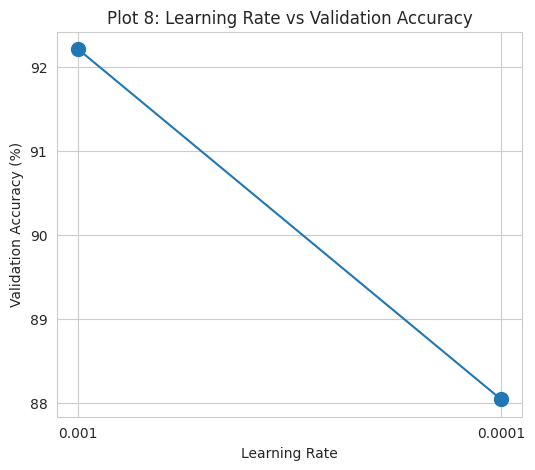

,Learning Rate,Val Accuracy
0,0.0010,0.922101
1,0.0001,0.880435


In [17]:
# ---- Learning Rate sweep (Plot 8) ----
lr_results = []
for lr in [0.001, 0.0001]:
    print(f"\nTraining with learning rate = {lr}")
    m, _ = build_mobilenet_model(dropout_rate=0.25, dense_units=128)
    m.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(train_ds, validation_data=val_ds, epochs=HP_EPOCHS, verbose=0)
    best_acc = max(hist.history["val_accuracy"])
    lr_results.append({"Learning Rate": lr, "Val Accuracy": best_acc})
    print(f"  Best val accuracy: {best_acc:.4f}")

lr_df = pd.DataFrame(lr_results)
plt.figure(figsize=(6, 5))
plt.plot(lr_df["Learning Rate"].astype(str), lr_df["Val Accuracy"] * 100, marker="o", markersize=10)
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 8: Learning Rate vs Validation Accuracy")
plt.show()
display(lr_df)


Training with batch size = 16
  Best val accuracy: 0.9185

Training with batch size = 32
  Best val accuracy: 0.9203

Training with batch size = 64
  Best val accuracy: 0.9130


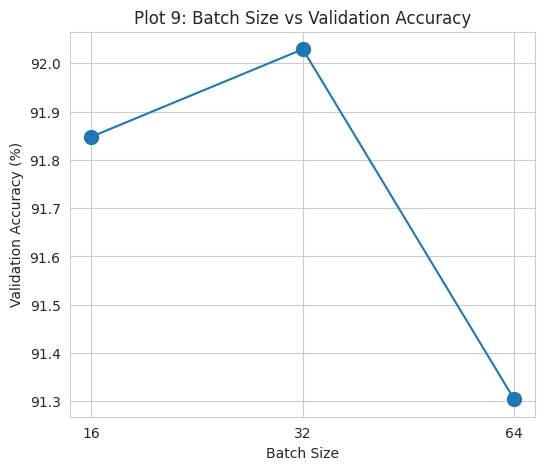

,Batch Size,Val Accuracy
0,16,0.918478
1,32,0.920290
2,64,0.913043


In [19]:
# ---- Batch Size sweep (Plot 9) ----
batch_results = []
for bs in [16, 32, 64]:
    print(f"\nTraining with batch size = {bs}")
    train_ds_bs = make_pipeline(train_raw, batch_size=bs, shuffle=True)
    val_ds_bs = make_pipeline(val_raw, batch_size=bs)
    m, _ = build_mobilenet_model(dropout_rate=0.25, dense_units=128)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(train_ds_bs, validation_data=val_ds_bs, epochs=HP_EPOCHS, verbose=0)
    best_acc = max(hist.history["val_accuracy"])
    batch_results.append({"Batch Size": bs, "Val Accuracy": best_acc})
    print(f"  Best val accuracy: {best_acc:.4f}")

batch_df = pd.DataFrame(batch_results)
plt.figure(figsize=(6, 5))
plt.plot(batch_df["Batch Size"].astype(str), batch_df["Val Accuracy"] * 100, marker="o", markersize=10)
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 9: Batch Size vs Validation Accuracy")
plt.show()
display(batch_df)


Training with dropout rate = 0.0
  Best val accuracy: 0.9239

Training with dropout rate = 0.25
  Best val accuracy: 0.9293

Training with dropout rate = 0.5
  Best val accuracy: 0.9330


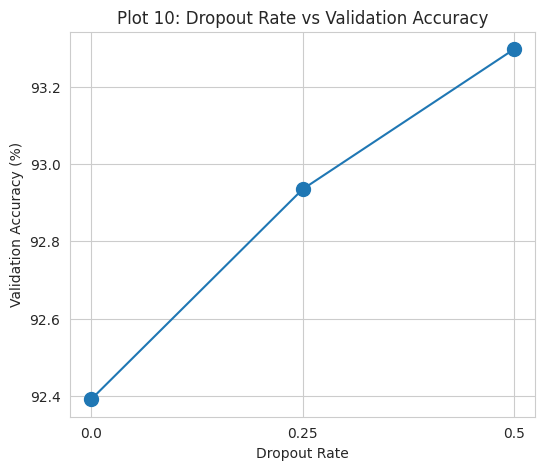

,Dropout Rate,Val Accuracy
0,0.00,0.923913
1,0.25,0.929348
2,0.50,0.932971



Best hyperparameters found: LR=0.001, Batch Size=32, Dropout=0.5


In [21]:
# ---- Dropout Rate sweep (Plot 10) ----
dropout_results = []
for dr in [0.0, 0.25, 0.5]:
    print(f"\nTraining with dropout rate = {dr}")
    m, _ = build_mobilenet_model(dropout_rate=dr, dense_units=128)
    m.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist = m.fit(train_ds, validation_data=val_ds, epochs=HP_EPOCHS, verbose=0)
    best_acc = max(hist.history["val_accuracy"])
    dropout_results.append({"Dropout Rate": dr, "Val Accuracy": best_acc})
    print(f"  Best val accuracy: {best_acc:.4f}")

dropout_df = pd.DataFrame(dropout_results)
plt.figure(figsize=(6, 5))
plt.plot(dropout_df["Dropout Rate"].astype(str), dropout_df["Val Accuracy"] * 100, marker="o", markersize=10)
plt.xlabel("Dropout Rate")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 10: Dropout Rate vs Validation Accuracy")
plt.show()
display(dropout_df)

# Record the best-performing value of each hyperparameter for later sections
BEST_LR = lr_df.loc[lr_df["Val Accuracy"].idxmax(), "Learning Rate"]
BEST_BATCH = int(batch_df.loc[batch_df["Val Accuracy"].idxmax(), "Batch Size"])
BEST_DROPOUT = dropout_df.loc[dropout_df["Val Accuracy"].idxmax(), "Dropout Rate"]
print(f"\nBest hyperparameters found: LR={BEST_LR}, Batch Size={BEST_BATCH}, Dropout={BEST_DROPOUT}")

In [22]:
FE_EPOCHS = 4

feature_extraction_model, fe_base = build_mobilenet_model(dropout_rate=BEST_DROPOUT, dense_units=128)
feature_extraction_model.compile(optimizer=Adam(learning_rate=BEST_LR),
                                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

train_ds_best = make_pipeline(train_raw, batch_size=BEST_BATCH, shuffle=True)
val_ds_best = make_pipeline(val_raw, batch_size=BEST_BATCH)

start_time = time.time()
history_fe = feature_extraction_model.fit(train_ds_best, validation_data=val_ds_best,
                                           epochs=FE_EPOCHS, verbose=1)
fe_time = time.time() - start_time
print(f"\nFeature extraction training time: {fe_time:.2f} seconds")

Epoch 1/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.6036 - loss: 1.4517 - val_accuracy: 0.8587 - val_loss: 0.4378
Epoch 2/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.8724 - loss: 0.4069 - val_accuracy: 0.9130 - val_loss: 0.2929
Epoch 3/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.9031 - loss: 0.2866 - val_accuracy: 0.8949 - val_loss: 0.3248
Epoch 4/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.9297 - loss: 0.2171 - val_accuracy: 0.9149 - val_loss: 0.2536

Feature extraction training time: 751.52 seconds


In [23]:
FT_EPOCHS = 4
FINE_TUNE_LR = 1e-4  # per the manual's suggested fine-tuning learning rate range (1e-4, 1e-5)

# Unfreeze the last block of MobileNetV2, keep everything before it frozen
fe_base.trainable = True
FINE_TUNE_AT = len(fe_base.layers) - 20
for layer in fe_base.layers[:FINE_TUNE_AT]:
    layer.trainable = False

feature_extraction_model.compile(optimizer=Adam(learning_rate=FINE_TUNE_LR),
                                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

start_time = time.time()
history_ft = feature_extraction_model.fit(train_ds_best, validation_data=val_ds_best,
                                           epochs=FT_EPOCHS, verbose=1)
ft_time = time.time() - start_time
print(f"\nFine-tuning training time: {ft_time:.2f} seconds")

Epoch 1/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.8910 - loss: 0.3162 - val_accuracy: 0.9185 - val_loss: 0.2247
Epoch 2/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 226s 2s/step - accuracy: 0.9409 - loss: 0.1670 - val_accuracy: 0.9167 - val_loss: 0.2166
Epoch 3/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9556 - loss: 0.1296 - val_accuracy: 0.9167 - val_loss: 0.2092
Epoch 4/4
98/98 ━━━━━━━━━━━━━━━━━━━━ 212s 2s/step - accuracy: 0.9699 - loss: 0.0962 - val_accuracy: 0.9257 - val_loss: 0.2304

Fine-tuning training time: 917.82 seconds


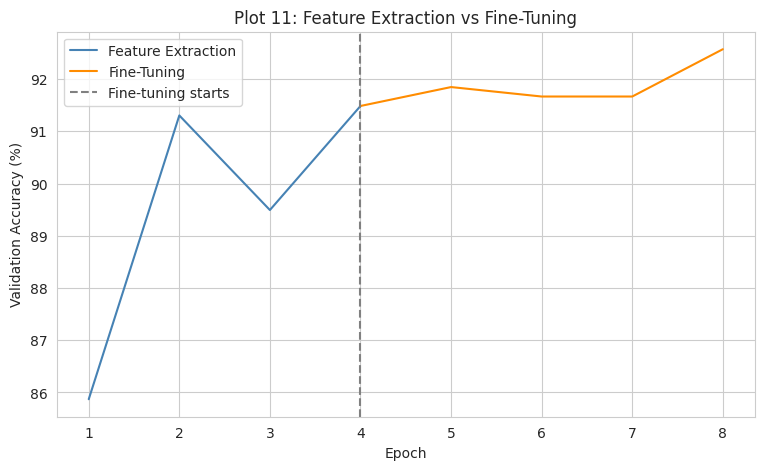

In [24]:
 # ---- Plot 11: Feature Extraction vs Fine-Tuning (continuous validation accuracy timeline) ----
combined_val_acc = history_fe.history["val_accuracy"] + history_ft.history["val_accuracy"]

plt.figure(figsize=(9, 5))
plt.plot(range(1, FE_EPOCHS + 1), np.array(history_fe.history["val_accuracy"]) * 100,
         label="Feature Extraction", color="steelblue")
plt.plot(range(FE_EPOCHS, FE_EPOCHS + FT_EPOCHS + 1),
         np.array([history_fe.history["val_accuracy"][-1]] + history_ft.history["val_accuracy"]) * 100,
         label="Fine-Tuning", color="darkorange")
plt.axvline(FE_EPOCHS, color="gray", linestyle="--", label="Fine-tuning starts")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Plot 11: Feature Extraction vs Fine-Tuning")
plt.legend()
plt.show()

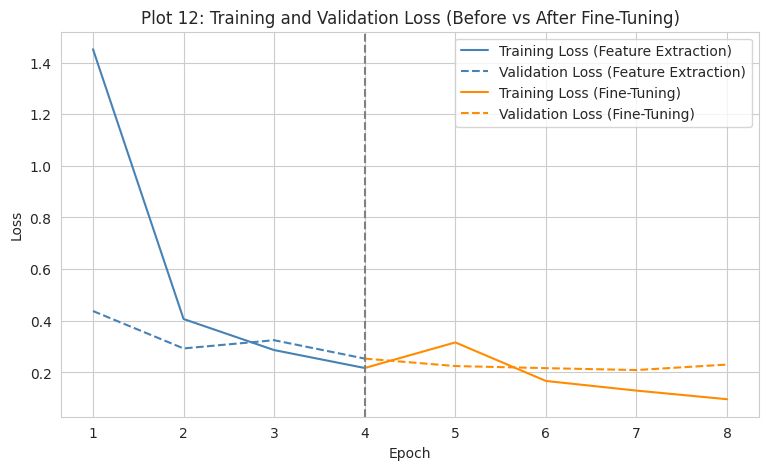

In [25]:
# ---- Plot 12: Training and Validation Loss (before vs after fine-tuning) ----
plt.figure(figsize=(9, 5))
plt.plot(range(1, FE_EPOCHS + 1), history_fe.history["loss"], label="Training Loss (Feature Extraction)", color="steelblue")
plt.plot(range(1, FE_EPOCHS + 1), history_fe.history["val_loss"], label="Validation Loss (Feature Extraction)", color="steelblue", linestyle="--")
plt.plot(range(FE_EPOCHS, FE_EPOCHS + FT_EPOCHS + 1),
         [history_fe.history["loss"][-1]] + history_ft.history["loss"], label="Training Loss (Fine-Tuning)", color="darkorange")
plt.plot(range(FE_EPOCHS, FE_EPOCHS + FT_EPOCHS + 1),
         [history_fe.history["val_loss"][-1]] + history_ft.history["val_loss"], label="Validation Loss (Fine-Tuning)", color="darkorange", linestyle="--")
plt.axvline(FE_EPOCHS, color="gray", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 12: Training and Validation Loss (Before vs After Fine-Tuning)")
plt.legend()
plt.show()

In [26]:
# Rebuild the full training pool (train + validation) as a single indexed array for K-Fold splitting
print("Loading full training pool into memory for K-Fold splitting (one-time cost)...")
all_images, all_pool_labels = [], []
for image, label in train_full.as_numpy_iterator():
    image_resized = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)).numpy()
    all_images.append(image_resized)
    all_pool_labels.append(label)
all_images = np.array(all_images, dtype="float32")
all_pool_labels = np.array(all_pool_labels)
print("Training pool shape:", all_images.shape)

Loading full training pool into memory for K-Fold splitting (one-time cost)...
Training pool shape: (3680, 224, 224, 3)


In [27]:
CV_EPOCHS = 4  # kept small: this section trains up to 4 configs x 5 folds = 20 models
N_SPLITS = 5

cv_configs = {
    "C1: Baseline":        {"lr": 0.001,   "batch": 32,        "dropout": 0.25, "finetune": False},
    "C2: Best Hyperparams":{"lr": BEST_LR, "batch": BEST_BATCH,"dropout": BEST_DROPOUT, "finetune": False},
    "C3: Fine-Tuned":      {"lr": BEST_LR, "batch": BEST_BATCH,"dropout": BEST_DROPOUT, "finetune": True},
    "C4: Higher Dropout":  {"lr": BEST_LR, "batch": BEST_BATCH,"dropout": 0.5,  "finetune": False},
}

def run_cv_config(config, images, labels, n_splits=N_SPLITS, epochs=CV_EPOCHS):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_accuracies = []
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(images), start=1):
        X_tr, y_tr = images[train_idx], labels[train_idx]
        X_val, y_val = images[val_idx], labels[val_idx]

        X_tr_p = preprocess_input(X_tr.copy())
        X_val_p = preprocess_input(X_val.copy())

        m, base = build_mobilenet_model(dropout_rate=config["dropout"], dense_units=128)
        if config["finetune"]:
            base.trainable = True
            ft_at = len(base.layers) - 20
            for layer in base.layers[:ft_at]:
                layer.trainable = False

        m.compile(optimizer=Adam(learning_rate=config["lr"]),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        m.fit(X_tr_p, y_tr, batch_size=config["batch"], epochs=epochs, verbose=0)

        _, fold_acc = m.evaluate(X_val_p, y_val, verbose=0)
        fold_accuracies.append(fold_acc)
        print(f"    Fold {fold_idx}: val accuracy = {fold_acc:.4f}")
    return fold_accuracies

In [ ]:
cv_results = {}
for config_name, config in cv_configs.items():
    print(f"\nRunning 5-fold CV for {config_name}...")
    fold_accs = run_cv_config(config, all_images, all_pool_labels)
    cv_results[config_name] = fold_accs
    print(f"  {config_name}: {np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}")


Running 5-fold CV for C1: Baseline...


In [ ]:
cv_table_rows = []
for config_name, fold_accs in cv_results.items():
    row = {"Configuration": config_name}
    for i, acc in enumerate(fold_accs, start=1):
        row[f"F{i}"] = round(acc, 4)
    row["Mean +/- SD"] = f"{np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}"
    cv_table_rows.append(row)

cv_table_df = pd.DataFrame(cv_table_rows)
display(cv_table_df)

In [ ]:
# ---- Plot 13: 5-Fold Cross-Validation Accuracy with error bars ----
config_names = list(cv_results.keys())
means = [np.mean(cv_results[c]) * 100 for c in config_names]
stds = [np.std(cv_results[c]) * 100 for c in config_names]

plt.figure(figsize=(9, 5))
plt.bar(config_names, means, yerr=stds, capsize=6, color="mediumseagreen")
plt.ylabel("Mean Validation Accuracy (%)")
plt.title("Plot 13: 5-Fold Cross-Validation Accuracy")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

BEST_CONFIG_NAME = max(cv_results, key=lambda c: np.mean(cv_results[c]))
print(f"\nBest configuration by mean CV accuracy: {BEST_CONFIG_NAME}")

In [ ]:
best_config = cv_configs[BEST_CONFIG_NAME]
print(f"Retraining final model using configuration: {BEST_CONFIG_NAME}")
print(best_config)

final_model, final_base = build_mobilenet_model(dropout_rate=best_config["dropout"], dense_units=128)
if best_config["finetune"]:
    final_base.trainable = True
    ft_at = len(final_base.layers) - 20
    for layer in final_base.layers[:ft_at]:
        layer.trainable = False

final_model.compile(optimizer=Adam(learning_rate=best_config["lr"]),
                     loss="sparse_categorical_crossentropy", metrics=["accuracy"])

full_train_ds = make_pipeline(train_full, batch_size=best_config["batch"], shuffle=True)

FINAL_EPOCHS = 10
start_time = time.time()
final_history = final_model.fit(full_train_ds, epochs=FINAL_EPOCHS, verbose=1)
final_training_time = time.time() - start_time
print(f"\nFinal model training time: {final_training_time:.2f} seconds")

In [ ]:
# ---- Evaluate ONCE on the official, untouched test set ----
y_pred_probs = final_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([label.numpy() for _, label in test_ds])

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
total_params = final_model.count_params()

cv_mean = np.mean(cv_results[BEST_CONFIG_NAME])
cv_sd = np.std(cv_results[BEST_CONFIG_NAME])

print(f"Mean CV Accuracy   : {cv_mean:.4f}")
print(f"CV Standard Dev.   : {cv_sd:.4f}")
print(f"Test Accuracy      : {test_accuracy:.4f}")
print(f"Precision (macro)  : {test_precision:.4f}")
print(f"Recall (macro)     : {test_recall:.4f}")
print(f"F1-score (macro)   : {test_f1:.4f}")
print(f"Training Time      : {final_training_time:.2f}s")
print(f"Total Parameters   : {total_params:,}")

In [ ]:
# ---- Plot 14: Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Plot 14: Confusion Matrix - Final Model on Test Set")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
# ---- Plot 15 (Optional): Sample Misclassified Images ----
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")

test_images_list = np.concatenate([img.numpy() for img, _ in test_ds])
sample_misclassified = np.random.choice(misclassified_idx, size=min(10, len(misclassified_idx)), replace=False)

plt.figure(figsize=(16, 7))
for i, idx in enumerate(sample_misclassified):
    plt.subplot(2, 5, i + 1)
    # Undo preprocess_input's scaling just for display purposes
    img_display = (test_images_list[idx] + 1.0) / 2.0
    plt.imshow(np.clip(img_display, 0, 1))
    plt.title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Plot 15: Sample Misclassified Images")
plt.tight_layout()
plt.show()

In [ ]:
overall_results = pd.DataFrame({
    "Configuration": ["Baseline (MobileNetV2, default settings)",
                       "Best Initialization (He, toy CNN)",
                       "Best Regularization (BatchNorm, toy CNN)",
                       "Best Optimizer (Adam, toy CNN)",
                       "Best Hyperparameters (MobileNetV2 CV)",
                       "Fine-Tuned Model (MobileNetV2 CV)"],
    "CV Accuracy": [
        round(np.mean(cv_results["C1: Baseline"]), 4),
        round(max(init_histories["He"]["val_accuracy"]), 4),
        round(max(reg_histories["batchnorm"]["val_accuracy"]), 4),
        round(max(opt_histories["Adam"]["val_accuracy"]), 4),
        round(np.mean(cv_results["C2: Best Hyperparams"]), 4),
        round(np.mean(cv_results["C3: Fine-Tuned"]), 4),
    ],
    "SD": [
        round(np.std(cv_results["C1: Baseline"]), 4),
        "--", "--", "--",
        round(np.std(cv_results["C2: Best Hyperparams"]), 4),
        round(np.std(cv_results["C3: Fine-Tuned"]), 4),
    ],
    "Test Accuracy": [
        "--", "--", "--", "--", "--",
        round(test_accuracy, 4) if BEST_CONFIG_NAME == "C3: Fine-Tuned" else "--"
    ],
    "Training Time (s)": [
        "--", "--", "--", "--", "--",
        round(final_training_time, 2) if BEST_CONFIG_NAME == "C3: Fine-Tuned" else "--"
    ]
})
display(overall_results)
print("\nNote: Test Accuracy and the final Training Time are only reported for whichever configuration")
print("was actually selected as the best (Section 12) and retrained on the full training pool --")
print("evaluating every row on the test set would violate the 'test set stays untouched' rule.")

In [ ]:
additional_configs = {
    "New-1: Low LR + Fine-tune":  {"lr": 1e-5, "batch": 32, "dropout": 0.25, "finetune": True},
    "New-2: High Dropout + Small Batch": {"lr": 0.001, "batch": 16, "dropout": 0.5, "finetune": False},
}

additional_cv_results = {}
for config_name, config in additional_configs.items():
    print(f"\nRunning 5-fold CV for {config_name}...")
    fold_accs = run_cv_config(config, all_images, all_pool_labels)
    additional_cv_results[config_name] = fold_accs
    print(f"  {config_name}: {np.mean(fold_accs):.4f} +/- {np.std(fold_accs):.4f}")

In [ ]:
comparison_names = [BEST_CONFIG_NAME] + list(additional_configs.keys())
comparison_means = [np.mean(cv_results[BEST_CONFIG_NAME]) * 100] + \
                    [np.mean(additional_cv_results[c]) * 100 for c in additional_configs.keys()]
comparison_stds = [np.std(cv_results[BEST_CONFIG_NAME]) * 100] + \
                   [np.std(additional_cv_results[c]) * 100 for c in additional_configs.keys()]

plt.figure(figsize=(9, 5))
plt.bar(comparison_names, comparison_means, yerr=comparison_stds, capsize=6, color="coral")
plt.ylabel("Mean CV Accuracy (%)")
plt.title("Additional Exercise: New Configurations vs Selected Best Configuration")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

for name, mean, sd in zip(comparison_names, comparison_means, comparison_stds):
    print(f"{name}: {mean:.2f}% +/- {sd:.2f}%")